# Face Detection with OpenCV

In this first blog of a new three part series in OpenCV, we will be covering face detection using OpenCV.

In [1]:
# @title Contact Software Sushi {"display-mode":"form"}
import base64
import requests
import urllib.request
from IPython.display import display, HTML

image_url = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/company/logo.png"
with urllib.request.urlopen(image_url) as response:
    image_data = response.read()
    encoded_image = base64.b64encode(image_data).decode()

def load_html_from_github(raw_url):
    response = requests.get(raw_url)
    html_content = response.text
    updated_html = html_content.replace('../images/logo.png', f"data:image/png;base64, {encoded_image}")
    display(HTML(updated_html))

load_html_from_github('https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/refs/heads/main/html/cta-banner-with-logo.html')

### Imports & Sample Images

In [2]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
import base64

from IPython.display import HTML, display
from io import BytesIO
from PIL import Image

In [3]:
# Collecting the sample image
image_url = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/face_detection/sample_face.jpeg"
resp = urllib.request.urlopen(image_url)
image_bytes = np.asarray(bytearray(resp.read()), dtype=np.uint8)

image_url_2 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv/face_detection/sample_faces.jpg"
resp_2 = urllib.request.urlopen(image_url_2)
image_bytes_2 = np.asarray(bytearray(resp_2.read()), dtype=np.uint8)

### Utils

In [4]:
# Function for the creation of flexible MatPlotLib figures
def create_mpl_figure(w,h,images,titles="Image",axis="off",color_maps=None):
    plt.figure(figsize=[w,h])

    for i, image in enumerate(images):
        plt.subplot(1,len(images),i+1);

        if color_maps is None:
            plt.imshow(image);
        elif len(color_maps) > 1:
            plt.imshow(image, cmap=f"{color_maps[i]}");
        else:
            plt.imshow(image, cmap=f"{color_maps[0]}")

        plt.title(titles[i]);
        plt.axis(axis);

## Face Detection Model Used

Though there are a variety of different techniques, libraries, and models used when it relates to face detection, the method we will be using today to achieve this goal is called the Haar Cascade Classifier. This method is extremely fast, does not demand much computational power, and comes prepackaged in OpenCV, removing the need for extra libraries.

As will be seen in the output, this method is not perfect, and will occasionally throw false positives or false negatives. Despite this, however, its flexibility and speed are exceedingly useful. Because of these traits, this model is often used as a pre-processing step in other techniques, namely, facial recognition, which will be the challenge we tackle in the next blog.

## Use Cases

Face Detection is an exceedingly common method in computer vision that is used for a variety of things. Whether it be biometric authentication, like can be done to unlock many modern cellphones, or detecting faces captured in CCTV footage, face detection has many different use cases.

## Utilizing the Haar Cascade Classifier

### Importing the Sample Images & Color Conversions

Like in the OpenCV fundamentals series, in this first section, we are decoding the sample image from our github repo, converting it into the RGB format for display, as well as into grayscale, so that it can be properly processed by the model.

In [5]:
# Decode the sample images
face_bgr_img = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)
faces_bgr_img = cv2.imdecode(image_bytes_2, cv2.IMREAD_COLOR)

# Color conversions & creations of copies for editing
face = cv2.cvtColor(face_bgr_img, cv2.COLOR_BGR2RGB)
face_edit = face.copy()

faces = cv2.cvtColor(faces_bgr_img, cv2.COLOR_BGR2RGB)
faces_edit = faces.copy()

# Convert the image to grayscale
face_gray = cv2.cvtColor(face_edit, cv2.COLOR_RGB2GRAY)
faces_gray = cv2.cvtColor(faces_edit, cv2.COLOR_RGB2GRAY)

### Preparing the Face Detector & Running the Model

In the second section, we initialize and process our images using the HCC. As is demonstrated below as well, this model has a few different things it can detect in addition to a person's face. In this case we are going to be looking for frontal faces in green and eyes in blue.

In each instance where we process our images, we are passing two arguments, scaleFactor, and minNeighbors.

scaleFactor is concerned with image scaling. It is a multi-step process that resizes the image multiple times, according to the float passed in the argument. If I were to pass 1.10, for instance, each resizing step would resize the image by 10%, 1.2 would resize by 20% per step and so on. The lower the number then, the more accurate your results will be, but they will be more time consuming.

minNeighbors is concerned with detection confidence. For each supposed face detected, they require x amount of "votes" from neighboring rectangles before it is submitted as an actual face. The amount of "votes" required from neighboring rectangles to determine whether or not the blob detected is a face is determined by you in an integer passed to minNeighbors. Higher values will result in less false-positives, but too high a value will filter legitimate results.

In [6]:
# Load the Haar cascade face detector
frontal_face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

eyes_face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Detect faces
detect_face = frontal_face_cascade.detectMultiScale(face_gray, scaleFactor=1.2, minNeighbors=6)

detect_faces = frontal_face_cascade.detectMultiScale(faces_gray, scaleFactor=1.2, minNeighbors=6)

# Detect eyes
detect_eyes = eyes_face_cascade.detectMultiScale(face_gray, scaleFactor = 1.2, minNeighbors=50)

detect_eyes_mult = eyes_face_cascade.detectMultiScale(faces_gray, scaleFactor = 1.2, minNeighbors=6)

### Draw Bounding Boxes

As the subtitle above suggests, now that we have processed the images through the model, we will now be drawing rectangles around the detected areas within the images.

- Green = Face
- Blue = Eyes

In [7]:
# Draw rectangles around detected faces
for (x, y, w, h) in detect_face:
    cv2.rectangle(face_edit, (x, y), (x + w, y + h), (0, 255, 0), 10)

for (x, y, w, h) in detect_faces:
    cv2.rectangle(faces_edit, (x, y), (x + w, y + h), (0, 255, 0), 1)

# Draw rectangles around detected eyes
for (x, y, w, h) in detect_eyes:
    cv2.rectangle(face_edit, (x, y), (x + w, y + h), (0, 0, 255), 10)

for (x, y, w, h) in detect_eyes_mult:
    cv2.rectangle(faces_edit, (x, y), (x + w, y + h), (0, 0, 255), 1)

### The Output

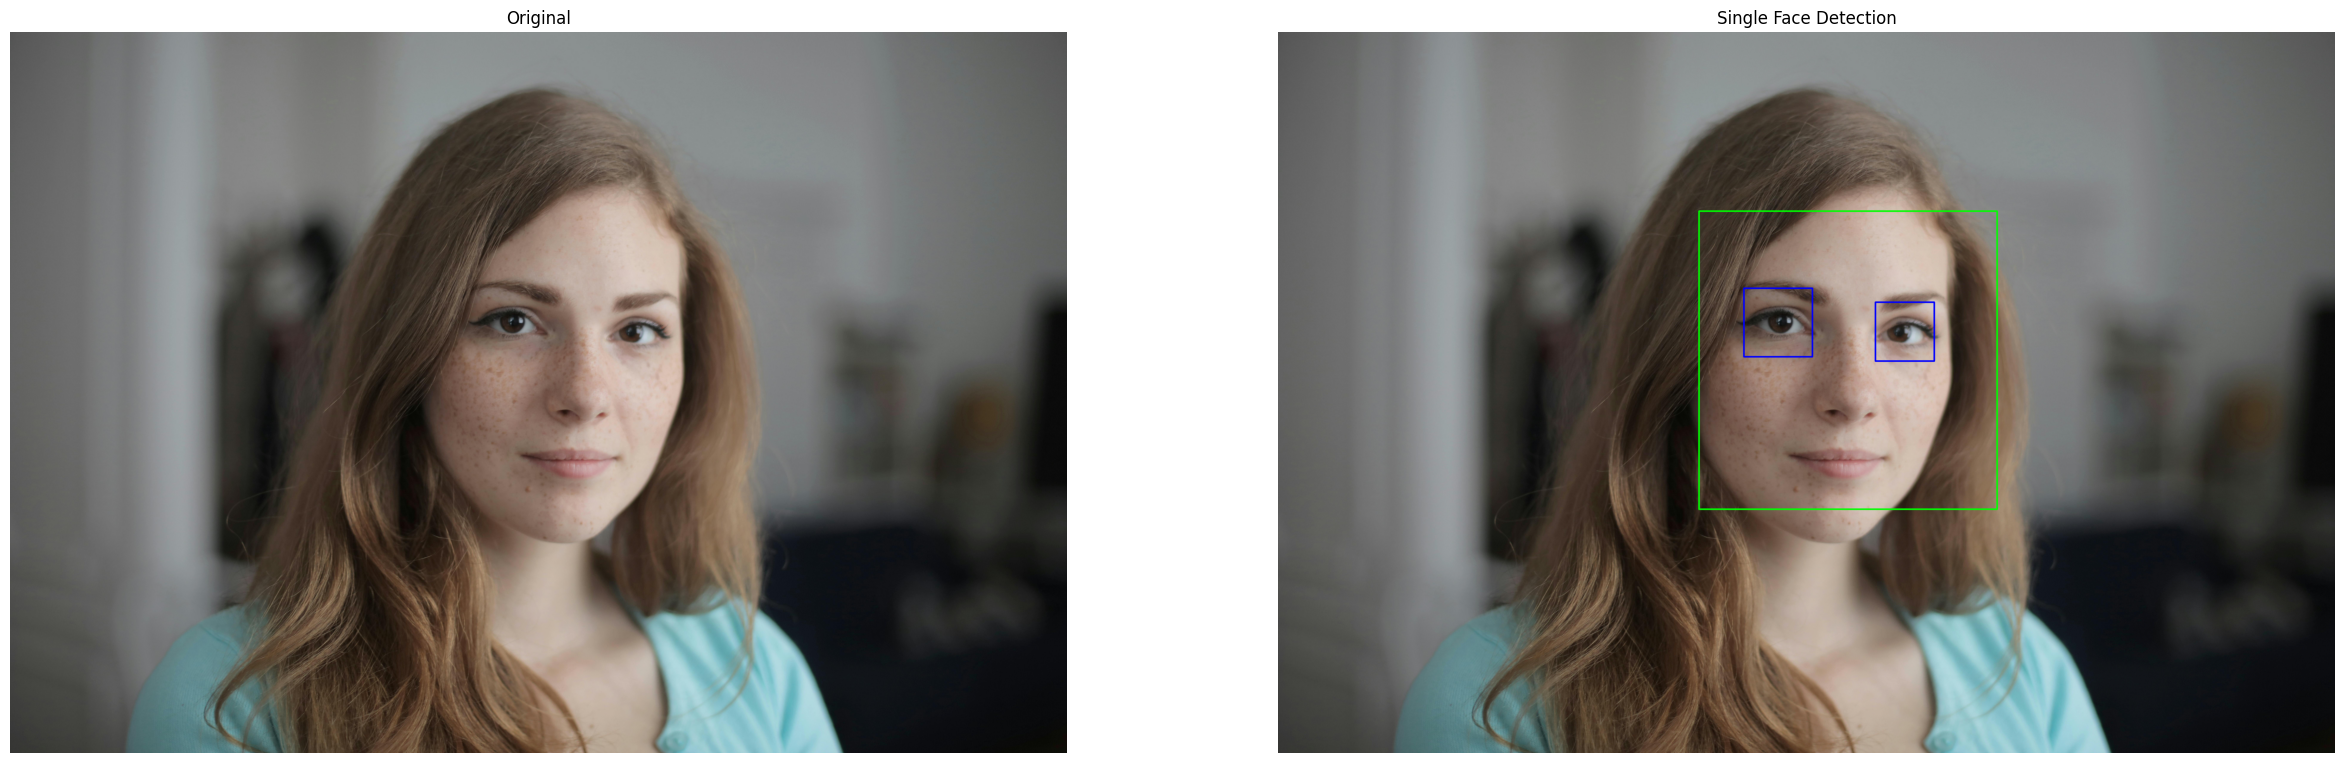

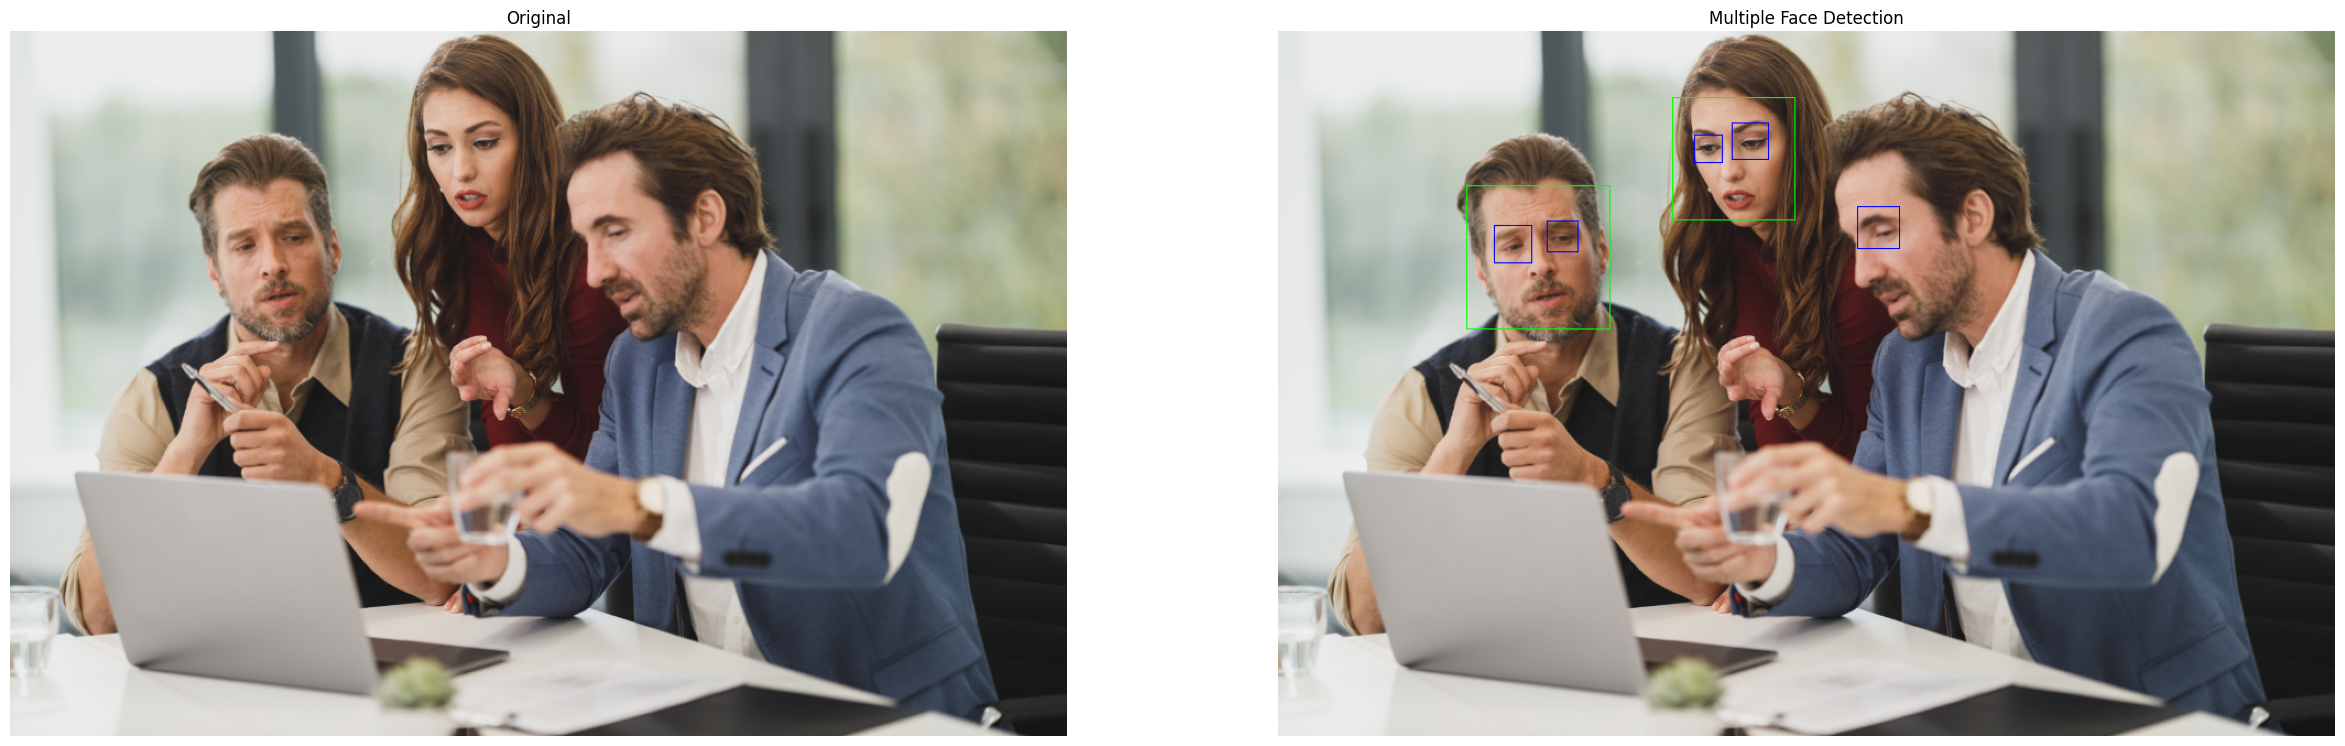

In [8]:
# Show the result
create_mpl_figure(30,10, [face, face_edit], ["Original", "Single Face Detection"])
create_mpl_figure(30,10, [faces, faces_edit], ["Original", "Multiple Face Detection"])

## Conclusion

That is how you do basic face detection using OpenCV! Using the Haar Cascade Classifier is relatively simple to use and very fast (enabling it to be used in real time!). In the next blog, we will be covering facial recognition.

In [ ]:
# @title Contact Software Sushi
load_html_from_github('https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/refs/heads/main/html/cta-banner.html')